# Summarizing Trajectories

## Preamble to Analysis

In [9]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import calendar
import pandas as pd
from datetime import datetime, timedelta
import os
from matplotlib.lines import Line2D

from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import matplotlib.ticker as ticker

import seaborn as sns
from shapely.geometry import Point, Polygon as ShapelyPolygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import imageio

import cmocean
import cmocean.cm as cmo
import importlib
import utils  # Importing the utils module


In [10]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
output_path = repo_path + 'processed_data/'

data_path = repo_path + 'data/'
fig_path = repo_path + 'figures/'

ibsco_path = data_path + 'IBSCO/'

tab_path = fig_path + 'tables/'
map_path = fig_path + 'maps/'

# Path to the downloaded NetCDF file
nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_APregion.nc'
# nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_SWSect.nc'

# Open the NetCDF file using xarray
ds_bathy = xr.open_dataset(nc_path)
# Extract the bathymetry data
bathymetry = ds_bathy['z']

# Tell it what to plot
to_plot = bathymetry

# Define depth intervals (e.g., every 500 meters)
depth_intervals = np.arange(-9000, 1000, 500)  # Adjust the range as needed

cmap=cmo.gray

In [11]:
#Files
start_file = 'IDLloc_spawning_21dfilter.csv'

starting_location_df=pd.read_csv(output_path + start_file) 

# List of simulations and locations
locations = ['BS', 'GERL', 'GP', 'MB2']

file = output_path + 'processed_trajectories_21dfilter.csv'

processed_df=pd.read_csv(file) 
print('raw number of larvae:', processed_df.larval_id.nunique())
df = processed_df.copy()

raw number of larvae: 11487


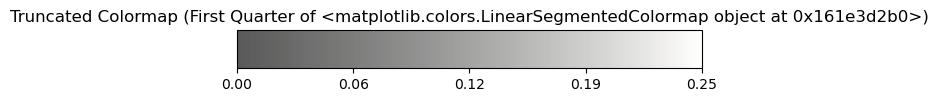

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker
import cmocean
import cmocean.cm as cmo

import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

from matplotlib.colors import LinearSegmentedColormap

# Define your custom colormap
perry_colors = ['#2892c6', '#6da9b3', '#9fc29a',
                '#cfde81', '#fafa64', '#fcc44d',
                '#fa8c33', '#f25822', '#e70f15']
perry_cmap = LinearSegmentedColormap.from_list("perry_colors", perry_colors)

# Create a truncated colormap

# Tighten colormap
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

truncated_cmap = truncate_colormap(cmap, 0.4, 1)

# Plot the truncated colormap
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create a color bar with the truncated colormap
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=truncated_cmap),
    cax=ax, orientation='horizontal', ticks=np.linspace(0, 1, 5)
)
cbar.ax.set_xticklabels([f'{x:.2f}' for x in np.linspace(0, 0.25, 5)])

# Add title and labels
cbar.ax.set_title(f'Truncated Colormap (First Quarter of {cmap})')

# Show the plot
plt.show()

In [13]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

# Import necessary data and functions from utils
hypotheses = utils.hypotheses
stages = utils.stages
locations = utils.locations
start_years = utils.start_years
months_data = utils.months_data
extents = utils.extents
bathymetry = utils.bathymetry

# function
plot_region = utils.plot_region
plot_contour = utils.plot_contour

importlib.reload(utils) # Run this if you update something in your utils file you need

boxes = {key: value['boxes'] for key, value in locations.items()}
location_labels = {key: value['name'] for key, value in locations.items()}
location_colors = {key: value['color'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

start_years = utils.start_years
sy_labels = {key: value['label'] for key, value in start_years.items()}
sy_marker = {key: value['marker'] for key, value in start_years.items()}

extent = [-76, -46, -71, -58]
print(extent)

[-76, -46, -71, -58]


In [14]:
# Helper function to plot the base map and all boxes
def plot_nurs_bw(ax, extent, locations, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Plot all bounding boxes
    for region, loc_data in locations.items():
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)

# Helper function to plot the base map and all boxes
def plot_nurseries_bw_fill(ax, extent, locations, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Plot all bounding boxes
    for region, loc_data in locations.items():
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=True, color ='k', alpha=0.1, zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)


# Helper function to plot the base map and specific nursery box
def plot_nurseries_individ(ax, extent, locations, nursery=None, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # If a specific nursery is provided, plot only that nursery
    if nursery in locations:
        loc_data = locations[nursery]
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)
    else:
        print(f"Nursery '{nursery}' not found in locations.")

# Helper function to plot the base map and all boxes
def plot_contour(ax, extent): #  boxes, box_zorder=6
    depth_int = np.arange(-1000, 0, 1000)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Plot the bathymetry contours on the same axis using contour for lines
    contour = ax.contour(bathymetry['lon'], bathymetry['lat'], bathymetry,
                         levels=depth_int, linestyles='solid', linewidths=0.5, colors='black', alpha=0.25,
                         transform=ccrs.PlateCarree(), zorder=5)  # Increased zorder

    # # Add small text in the bottom right corner
    # ax.annotate('IBCSO v2 \n 1000m isobath', xy=(1, 0), xycoords='axes fraction',
    #             fontsize=6, xytext=(-5, 5), textcoords='offset points', ha='right', va='bottom')

In [ ]:
%%time

# Quick Test of things

# Define your extent and bathymetry grid
extent = [-76, -46, -71, -58]
masked_bathymetry = np.ma.masked_invalid(bathymetry)

fig, axs = plt.subplots(1, 1, figsize=(6, 6),
                        subplot_kw={'projection': ccrs.SouthPolarStereo()})

ax = axs  # only one subplot in this case

# Plot region and contours (assumes you have helper functions for those)
plot_region(ax, extent)
# plot_contour(ax, extent)

cmap = truncated_cmap  # use your preferred colormap
bathy_plot = ax.pcolormesh(
    bathymetry['lon'], bathymetry['lat'],
    masked_bathymetry, cmap=cmap,
    transform=ccrs.PlateCarree(), zorder=0
)

cbar = fig.colorbar(bathy_plot, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('Depth (m)', fontsize=10)

## Functions to Process Data

In [16]:
def add_transition_columns(df, locations):
    """
    Add transition columns for immigration, emigration, and states for each location.
    Transition states:
    - 'initial_inside': first point and inside the NG
    - 'initial_outside': first point and outside the NG
    - 'immigrate': transitioned into NG from outside
    - 'exited': transitioned out of NG but may return later
    - 'inside': remained inside NG
    - 'outside': remained outside NG
    Note: use `*_final_emigrate` for irreversible departures.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame.
        locations (list): List of location names (e.g., ['BS', 'GERL', 'GP', 'MB']).
    
    Returns:
        pd.DataFrame: DataFrame with added transition columns.
    """
    def categorize_transition(prev, curr):
        if pd.isna(prev):
            return 'initial_inside' if curr else 'initial_outside'
        if not prev and curr:
            return 'immigrate'
        elif prev and not curr:
            return 'exited'
        elif prev and curr:
            return 'inside'
        else:
            return 'outside'

    for loc in locations:
        prev_col = f'{loc}_prev'
        trans_col = f'{loc}_transition'

        # Add previous state column
        df[prev_col] = df.groupby('larval_id')[loc].shift(1)
        
        # Add transition column
        df[trans_col] = [categorize_transition(p, c) for p, c in zip(df[prev_col], df[loc])]

    return df


In [40]:
def add_final_exit_column(df, locations):
    """
    For each location, add a boolean column indicating if the emigrate event
    was the final departure (i.e., no return after this point).
    """
    for loc in locations:
        trans_col = f'{loc}_transition'
        presence_col = loc
        final_ex_col = f'{loc}_final_exit'
        df[final_ex_col] = False  # default

        for larva_id, group in df.groupby('larval_id'):
            transitions = group[trans_col].values
            inside = group[presence_col].values
            indices = group.index.values

            exit_positions = np.where(transitions == 'exited')[0]
            for i in reversed(exit_positions):  # ← reverse loop to find *last* valid exit
                after_i = inside[i + 1:] if i + 1 < len(inside) else []
                if not any(after_i):  # if never comes back inside
                    df.at[indices[i], final_ex_col] = True
                    break  # stop after finding the correct final exit

    return df

In [77]:
def get_pre_post_data(df, idl_loc, hyp, SY):
    """
    Extract pre-immigration, post-final-emigration, local-spawned, and full data
    for a given nursery, hypothesis, and start year.
    """
    subset = df[(df['start_year'] == SY) & (df['hypothesis'] == hyp)]
    if idl_loc:
        subset = subset[subset['IDL_loc'] == idl_loc]

    all_larvae = subset['larval_id'].unique()
    pre_imm_list, post_ex_list, local_spawn_list = [], [], []

    trans_col = f'{idl_loc}_transition'
    final_ex_col = f'{idl_loc}_final_exit'

    for larva in all_larvae:
        larva_data = subset[subset['larval_id'] == larva].sort_values('date').reset_index(drop=True)
        transitions = larva_data[trans_col].values
        final_ex_flags = larva_data[final_ex_col].values

        # Locally spawned — keep full trajectory
        if 'initial_inside' in transitions:
            local_spawn_list.append(larva_data)
            continue  # Don't double-count

        # Immigrated — keep only before the first immigration, skip any further use
        if 'immigrate' in transitions:
            imm_pos = np.where(transitions == 'immigrate')[0][0]
            if imm_pos > 0:
                pre_imm_list.append(larva_data.iloc[:imm_pos])
            continue  # 🛑 Skip final exit

        # Final emigration — keep only after that point
        if final_ex_flags.any():
            final_ex_pos = np.where(final_ex_flags)[0][0]
            if final_ex_pos + 1 < len(larva_data):
                post_ex_list.append(larva_data.iloc[final_ex_pos + 1:])

    # Combine
    all_pre_imm = pd.concat(pre_imm_list, ignore_index=True) if pre_imm_list else pd.DataFrame()
    all_post_ex = pd.concat(post_ex_list, ignore_index=True) if post_ex_list else pd.DataFrame()
    all_local_spawn = pd.concat(local_spawn_list, ignore_index=True) if local_spawn_list else pd.DataFrame()
    all_full = subset.copy()  # all rows matching SY, hyp, IDL_loc

    return all_pre_imm, all_post_ex, all_local_spawn, all_full

In [78]:
def preprocess_all_data(df, nurseries, years, hypothesis):
    """
    Construct data_store with pre-immigration, post-final-emigration, 
    local-spawned, and full trajectories for each nursery/year.
    """
    data_store = {}
    for nursery in nurseries:
        for year in years:
            pre, post, local, full = get_pre_post_data(df, nursery, hypothesis, year)
            data_store[(nursery, year)] = (pre, post, local, full)
    return data_store

In [79]:
#Apply Processing:
df = add_transition_columns(df, locations)
df = add_final_exit_column(df, locations)
df

,N,T,date,lat,lon,release,stage,larval_id,start_year,hypothesis,...,GERL_transition,GP_prev,GP_transition,MB2_prev,MB2_transition,BS_final_emigrate,BS_final_exit,GERL_final_exit,GP_final_exit,MB2_final_exit
0,2,0,2016-11-01,-63.602314,298.26752,0,0,00_16_1_0003,2016,h_null,...,initial_outside,NaN,initial_outside,NaN,initial_outside,False,False,False,False,False
1,2,1,2016-11-02,-63.569042,298.23145,0,0,00_16_1_0003,2016,h_null,...,outside,False,outside,False,outside,False,False,False,False,False
2,2,2,2016-11-03,-63.522503,298.25543,0,0,00_16_1_0003,2016,h_null,...,outside,False,outside,False,outside,False,False,False,False,False
3,2,3,2016-11-04,-63.483067,298.28790,0,0,00_16_1_0003,2016,h_null,...,outside,False,outside,False,outside,False,False,False,False,False
4,2,4,2016-11-05,-63.438553,298.33795,0,0,00_16_1_0003,2016,h_null,...,outside,False,outside,False,outside,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2067655,198,175,2019-09-12,-61.923122,299.13315,10,4,00_18_1_0199,2018,h_null,...,outside,False,outside,False,outside,False,False,False,False,False
2067656,198,176,2019-09-13,-61.860650,299.25064,10,4,00_18_1_0199,2018,h_null,...,outside,False,outside,False,outside,False,False,False,False,False
2067657,198,177,2019-09-14,-61.813430,299.41430,10,4,00_18_1_0199,2018,h_null,...,outside,False,outside,False,outside,False,False,False,False,False
2067658,198,178,2019-09-15,-61.756500,299.58655,10,4,00_18_1_0199,2018,h_null,...,outside,False,outside,False,outside,False,False,False,False,False


# Visual DeBug

In [80]:

# # Select and sort the larva trajectory
# larva = '00_16_1_0003'
# d = df[df['larval_id'] == larva].sort_values('date').reset_index(drop=True)

# # Find the final exit point index (should be exactly one True)
# exit_idx = d.index[d['BS_final_exit']].tolist()

# # Plot full path
# plt.plot(d['lon'], d['lat'], color='gray', label='Full trajectory')

# # Plot red dot at the final exit location (if it exists)
# if exit_idx:
#     final_exit_index = exit_idx[0]
#     plt.scatter(d.loc[final_exit_index, 'lon'], d.loc[final_exit_index, 'lat'], 
#                 color='red', label='Final exit')

#     # Plot segment after final exit (dashed)
#     if final_exit_index + 1 < len(d):
#         post_ex = d.loc[final_exit_index + 1:]
#         plt.plot(post_ex['lon'], post_ex['lat'], 
#                  color='black', linestyle='--', linewidth=1.5, label='After final exit')
#     else:
#         print(f"⚠️ No trajectory after final exit for {larva}")
# else:
#     print(f"❌ No BS_final_exit found for {larva}")

# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title(f"Trajectory for larva {larva}")
# plt.legend()
# plt.grid(True)
# plt.show()

# Plot it propper

In [125]:
def plot_dual_panel_migration_tracks(data_store, nursery, years, hypothesis, extent, save_path=None):
    """
    Plot a 2-panel figure showing immigration (left) and emigration (right) tracks 
    for multiple years to/from a nursery ground, using year-specific colors.
    Panel A: Trajectories before final entry to the NG
    Panel B: Trajectories after final exit from the NG
    """
    if save_path is None:
        year_str = f"{min(years)}-{max(years)}" if len(years) > 1 else f"{years[0]}"
        save_path = f'figures/{nursery}_migration_tracks_dual_panel_{hypothesis}_{year_str}.png'

    start_years = {
        2016: {'label': 'sy 2016', 'marker': 'o', 'color': '#648fff'},
        2017: {'label': 'sy 2017', 'marker': 's', 'color': '#dc267f'},
        2018: {'label': 'sy 2018', 'marker': '^', 'color': '#ffb000'}
    }

    fig, axs = plt.subplots(1, 2, figsize=(13, 6),
                            subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65)},
                            constrained_layout=True)

    # --- Panel A: Pre-Final-Entry Trajectories ---
    ax_imm = axs[0]
    plot_region(ax_imm, extent)
    plot_contour(ax_imm, extent)
    plot_nurseries_individ(ax_imm, extent, locations, nursery)
    legend_handles = []

    for yr in years:
        pre_imm, _, _, _ = data_store.get((nursery, yr), (pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()))
        style = start_years.get(yr, {'label': str(yr), 'color': 'gray'})

        if not pre_imm.empty:
            for larva_id, traj in pre_imm.groupby('larval_id'):
                traj = traj.sort_values('date')
                ax_imm.plot(
                    traj['lon'],
                    traj['lat'],
                    color=style['color'], alpha=0.4, linewidth=0.6,
                    transform=ccrs.PlateCarree()
                )

            legend_handles.append(Line2D([0], [0], color=style['color'], lw=1.5, alpha=0.6, label=f"{yr}"))
        else:
            print(f"⚠️ No immigration data for {nursery} {yr}")

    ax_imm.set_title(f"{location_labels.get(nursery, nursery)}-NG\nLarval Import Paths", fontsize=12)
    ax_imm.legend(handles=legend_handles, loc='lower right', fontsize=9)
    contour_imm = ax_imm.contourf(
        bathymetry['lon'], bathymetry['lat'], masked_bathymetry,
        levels=depth_intervals, cmap=truncated_cmap, transform=ccrs.PlateCarree(), zorder=0
    )
    ax_imm.text(0.02, 0.93, "A", transform=ax_imm.transAxes,
                fontsize=16, fontweight='bold', ha='left', va='bottom')

    # --- Panel B: Post-Final-Exit Trajectories ---
    ax_ex = axs[1]
    plot_region(ax_ex, extent)
    plot_contour(ax_ex, extent)
    plot_nurseries_individ(ax_ex, extent, locations, nursery)
    legend_handles = []

    for yr in years:
        _, _, _, full_subset = data_store.get((nursery, yr), (pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()))
        style = start_years.get(yr, {'label': str(yr), 'color': 'gray'})

        if not full_subset.empty:
            for larva_id, traj in full_subset.groupby('larval_id'):
                traj = traj.sort_values('date')
                final_exit_flags = traj.get(f'{nursery}_final_exit', None)
                if final_exit_flags is None:
                    continue
                final_exit_idx = np.where(final_exit_flags.values)[0]

                if len(final_exit_idx) == 0:
                    continue  # No final exit for this larva

                i = final_exit_idx[0]
                if i + 1 < len(traj):
                    ax_ex.plot(
                        traj.iloc[i+1:]['lon'],
                        traj.iloc[i+1:]['lat'],
                        color=style['color'], alpha=0.4, linewidth=0.6,
                        transform=ccrs.PlateCarree()
                    )

            legend_handles.append(Line2D([0], [0], color=style['color'], lw=1.5, alpha=0.6, label=f"{yr}"))
        else:
            print(f"⚠️ No export data for {nursery} {yr}")

    ax_ex.set_title(f"{location_labels.get(nursery, nursery)}-NG\nLarval Export Paths", fontsize=12)
    ax_ex.legend(handles=legend_handles, loc='lower right', fontsize=9)
    ax_ex.contourf(
        bathymetry['lon'], bathymetry['lat'], masked_bathymetry,
        levels=depth_intervals, cmap=truncated_cmap, transform=ccrs.PlateCarree(), zorder=0
    )
    ax_ex.text(0.02, 0.93, "B", transform=ax_ex.transAxes,
               fontsize=16, fontweight='bold', ha='left', va='bottom')
    
    # --- Shared Colorbar ---
    cbar = fig.colorbar(contour_imm, ax=axs, orientation='vertical', shrink=0.6, pad=0.02)
    cbar.set_label('Depth (m)', fontsize=10)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved to {save_path}")
    plt.show()

✅ Saved to figures/manuscript-versions/BS_migration_tracks_h_dvm_revised.png


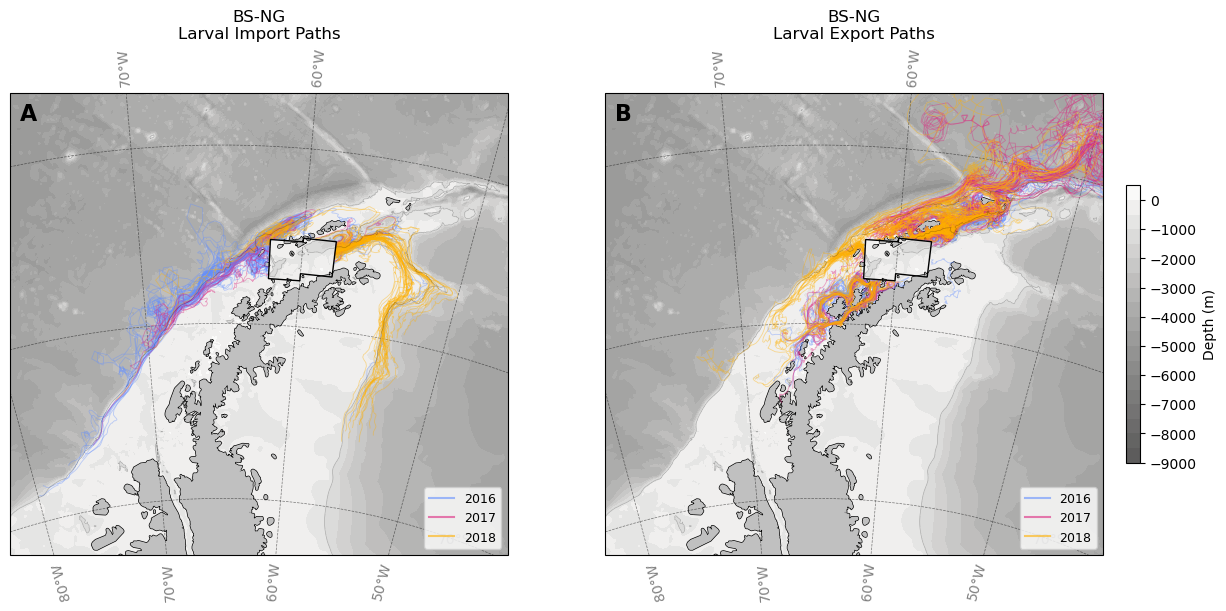

In [126]:
nurseries = ['BS']#, 'GP', 'MB2']
hypotheses = ['h_dvm']#, 'h_size']
years = [2016, 2017, 2018]
extent = [-76, -50, -71, -58]  # Adjust if needed per region
file_path = 'figures/manuscript-versions/'
for nursery in nurseries:
    for hypothesis in hypotheses:
        data_store = preprocess_all_data(df, [nursery], years, hypothesis)
        save_path = f'{file_path}{nursery}_migration_tracks_{hypothesis}_revised.png'
        
        plot_dual_panel_migration_tracks(
            data_store=data_store,
            nursery=nursery,
            years=years,
            hypothesis=hypothesis,
            extent=extent,
            save_path=save_path
        )
        

✅ Saved to figures/manuscript-versions/BS_migration_tracks_h_dvm_revised.pdf


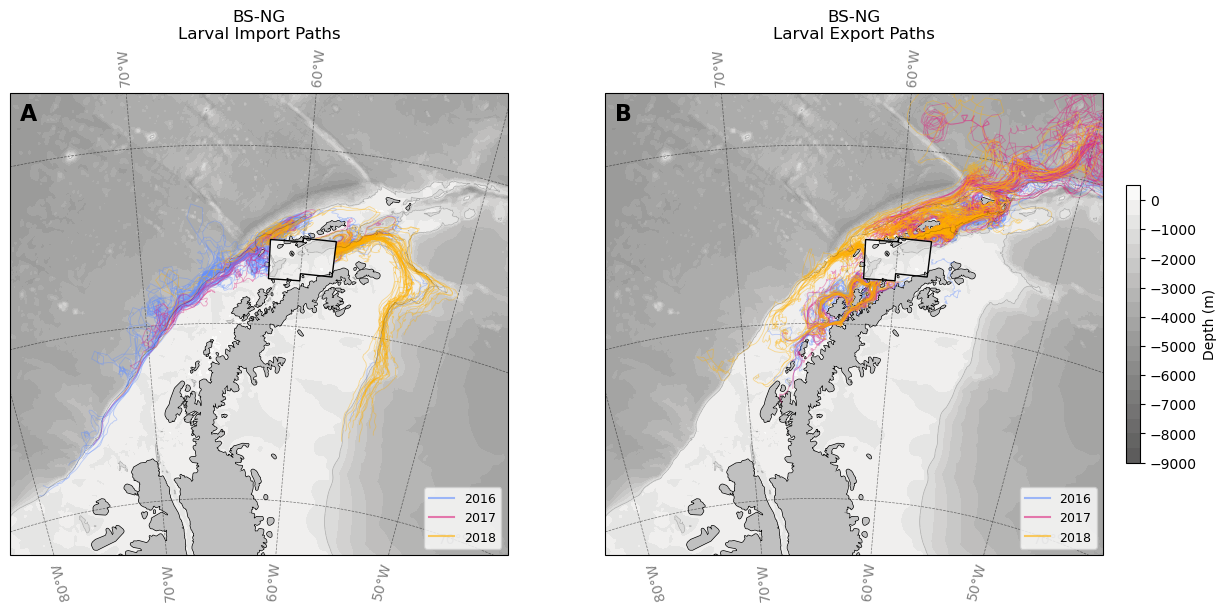

In [127]:
nurseries = ['BS']#, 'GP', 'MB2']
hypotheses = ['h_dvm']#, 'h_size']
years = [2016, 2017, 2018]
extent = [-76, -50, -71, -58]  # Adjust if needed per region
file_path = 'figures/manuscript-versions/'
for nursery in nurseries:
    for hypothesis in hypotheses:
        data_store = preprocess_all_data(df, [nursery], years, hypothesis)
        save_path = f'{file_path}{nursery}_migration_tracks_{hypothesis}_revised.pdf'
        
        plot_dual_panel_migration_tracks(
            data_store=data_store,
            nursery=nursery,
            years=years,
            hypothesis=hypothesis,
            extent=extent,
            save_path=save_path
        )
        

✅ Saved to figures/MB2_migration_tracks_dual_panel_h_dvm_2016-2018_revised.png


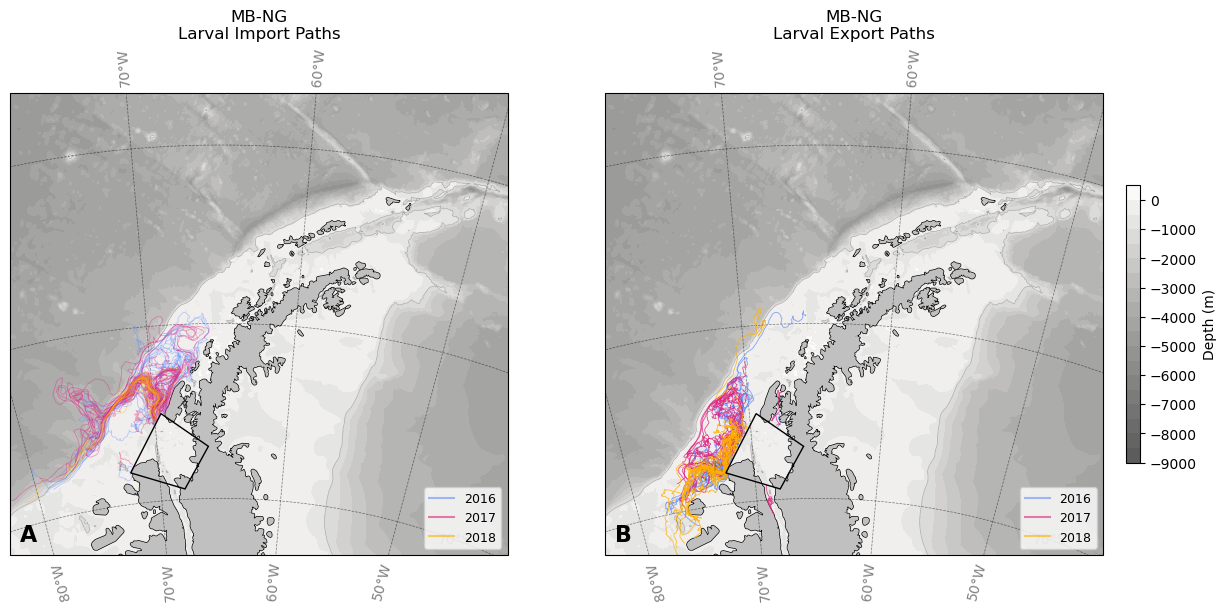

✅ Saved to figures/MB2_migration_tracks_dual_panel_h_size_2016-2018_revised.png


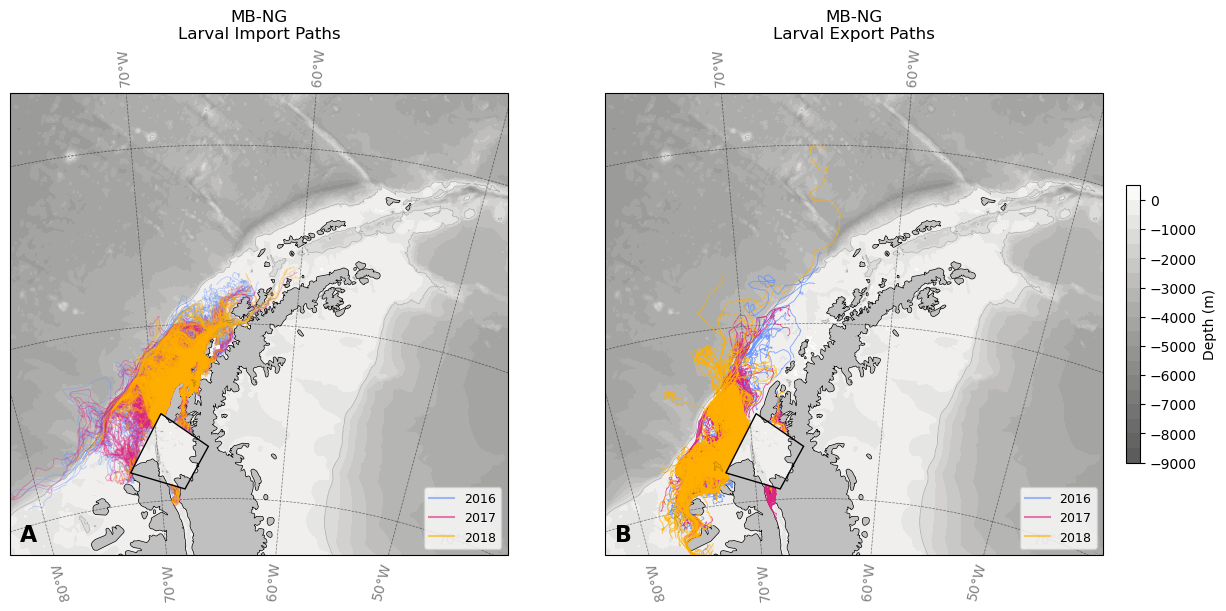

In [85]:
nurseries = ['MB2']#, 'GP', 'MB2']
hypotheses = ['h_dvm', 'h_size']
years = [2016, 2017, 2018]
extent = [-76, -50, -71, -58]  # Adjust if needed per region

for nursery in nurseries:
    for hypothesis in hypotheses:
        data_store = preprocess_all_data(df, [nursery], years, hypothesis)
        save_path = f'figures/{nursery}_migration_tracks_dual_panel_{hypothesis}_{years[0]}-{years[-1]}_revised.png'
        
        plot_dual_panel_migration_tracks(
            data_store=data_store,
            nursery=nursery,
            years=years,
            hypothesis=hypothesis,
            extent=extent,
            save_path=save_path
        )
        

✅ Saved to figures/BS_migration_tracks_dual_panel_h_size_2016-2018_revised.png


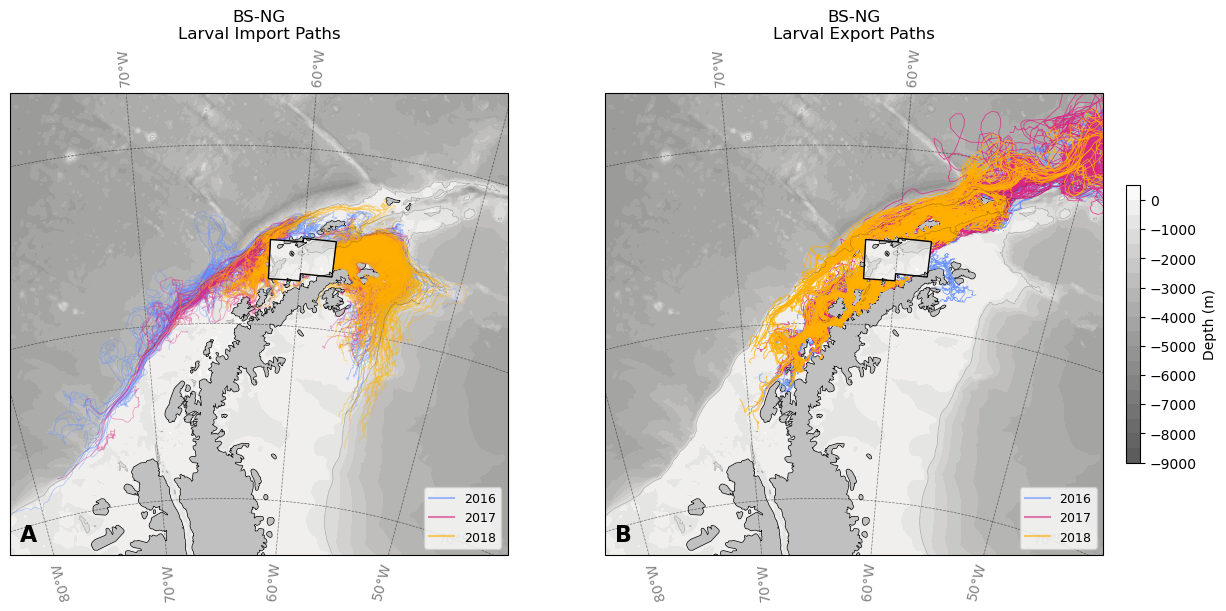

In [86]:
nurseries = ['BS']#, 'GP', 'MB2']
hypotheses = ['h_size']
years = [2016, 2017, 2018]
extent = [-76, -50, -71, -58]  # Adjust if needed per region

for nursery in nurseries:
    for hypothesis in hypotheses:
        data_store = preprocess_all_data(df, [nursery], years, hypothesis)
        save_path = f'figures/{nursery}_migration_tracks_dual_panel_{hypothesis}_{years[0]}-{years[-1]}_revised.png'
        
        plot_dual_panel_migration_tracks(
            data_store=data_store,
            nursery=nursery,
            years=years,
            hypothesis=hypothesis,
            extent=extent,
            save_path=save_path
        )
        

✅ Saved to figures/GP_migration_tracks_dual_panel_h_dvm_2016-2018_revised.png


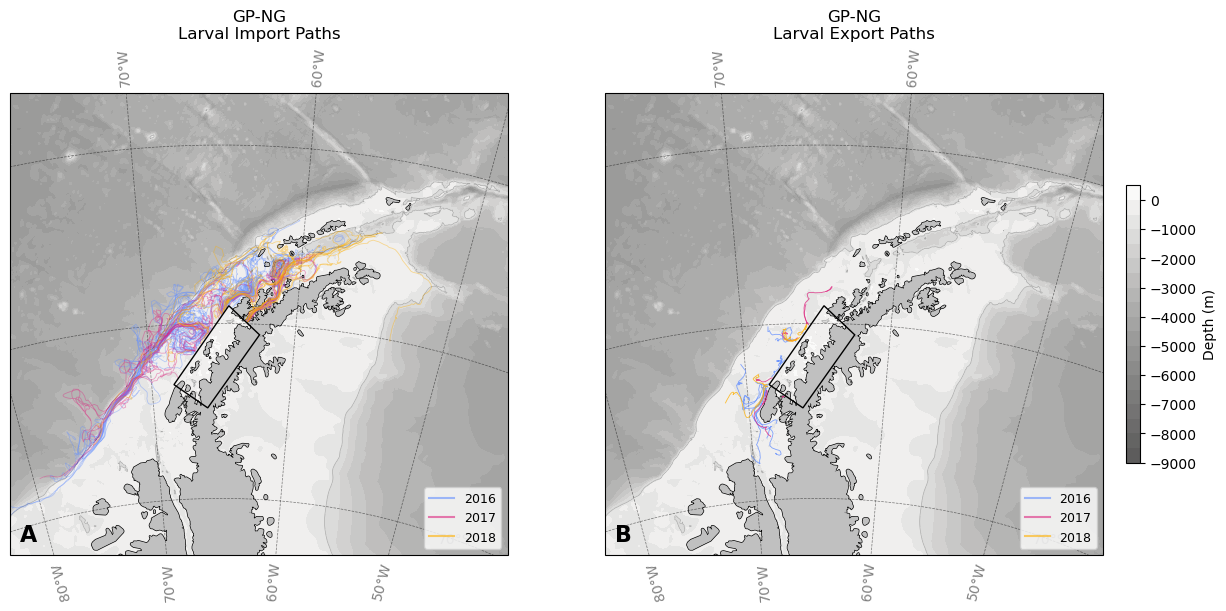

✅ Saved to figures/GP_migration_tracks_dual_panel_h_size_2016-2018_revised.png


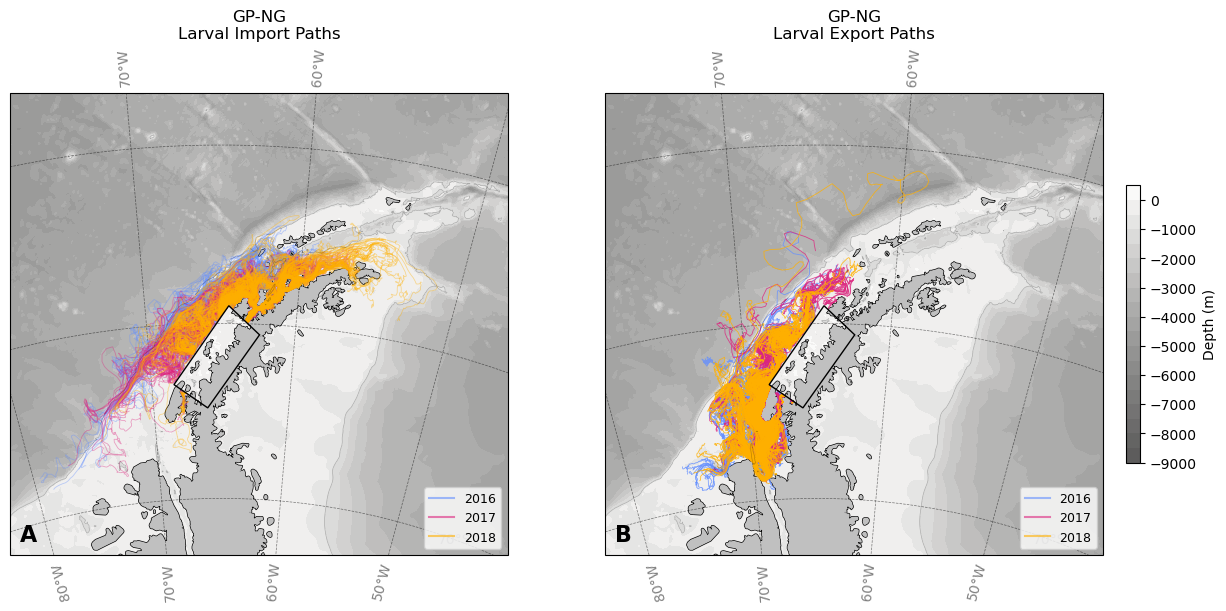

In [87]:
nurseries = ['GP']
hypotheses = ['h_dvm', 'h_size']
years = [2016, 2017, 2018]
extent = [-76, -50, -71, -58]  # Adjust if needed per region

for nursery in nurseries:
    for hypothesis in hypotheses:
        data_store = preprocess_all_data(df, [nursery], years, hypothesis)
        save_path = f'figures/{nursery}_migration_tracks_dual_panel_{hypothesis}_{years[0]}-{years[-1]}_revised.png'
        
        plot_dual_panel_migration_tracks(
            data_store=data_store,
            nursery=nursery,
            years=years,
            hypothesis=hypothesis,
            extent=extent,
            save_path=save_path
        )
        

✅ Saved to figures/GERL_migration_tracks_dual_panel_h_dvm_2016-2018_revised.png


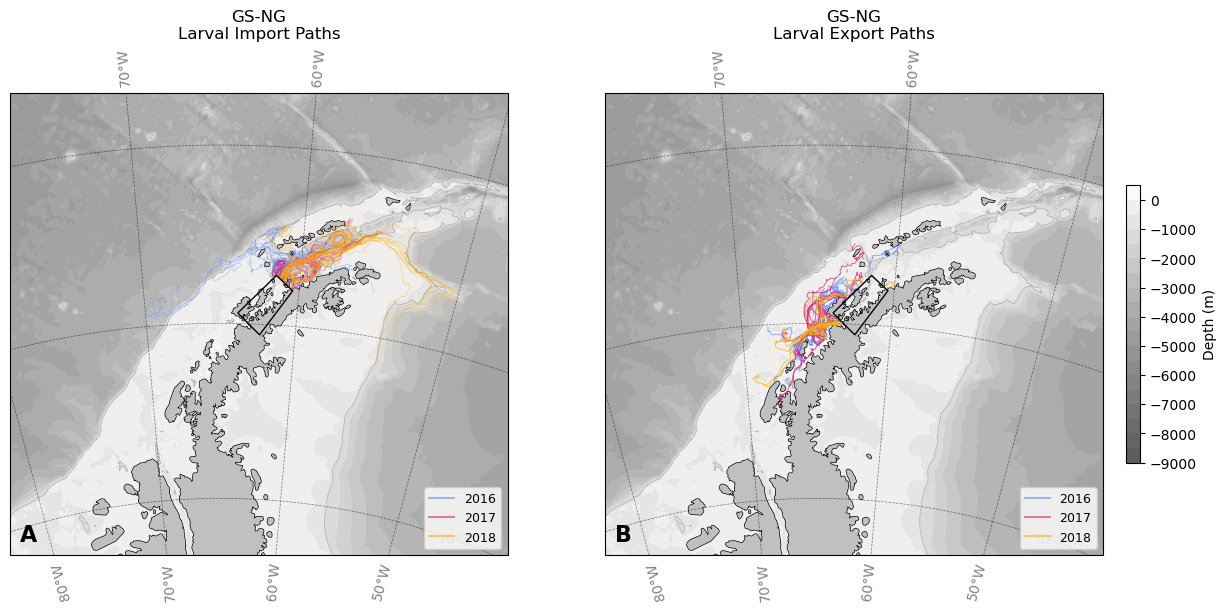

✅ Saved to figures/GERL_migration_tracks_dual_panel_h_size_2016-2018_revised.png


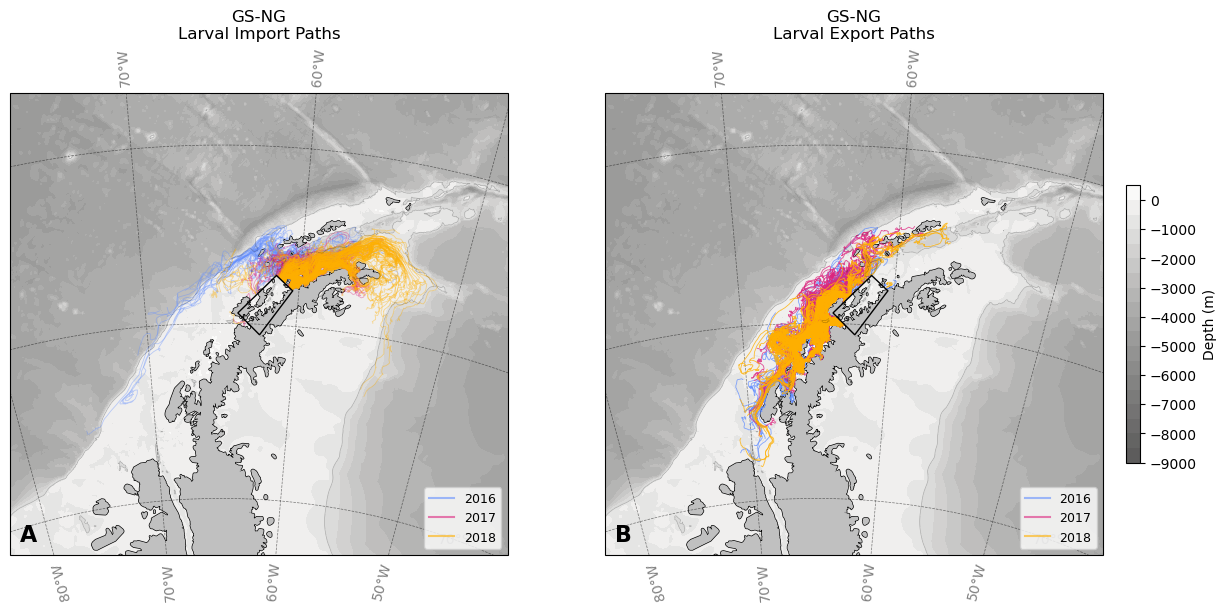

In [113]:
nurseries = ['GERL']
hypotheses = ['h_dvm', 'h_size']
years = [2016, 2017, 2018]
extent = [-76, -50, -71, -58]  # Adjust if needed per region

for nursery in nurseries:
    for hypothesis in hypotheses:
        data_store = preprocess_all_data(df, [nursery], years, hypothesis)
        save_path = f'figures/{nursery}_migration_tracks_dual_panel_{hypothesis}_{years[0]}-{years[-1]}_revised.png'
        
        plot_dual_panel_migration_tracks(
            data_store=data_store,
            nursery=nursery,
            years=years,
            hypothesis=hypothesis,
            extent=extent,
            save_path=save_path
        )
        

# Visualize spatial density of larval tracks:
	•	Import density: where larvae tend to come from prior to final entry into the NG.
	•	Export density: where larvae tend to go after their final exit from the NG.

Strategy Options:

1. Accumulate Tracks into a 2D Density Histogram
	•	Bin all coordinates (lon, lat) of relevant trajectory segments (pre-immigration or post-emigration).
	•	Create a 2D histogram (e.g. using numpy.histogram2d) to count how often drifters pass through each bin.
	•	Optionally normalize to create a density map (0–1 or % of max).

2. Use a KDE (Kernel Density Estimate)
	•	Use seaborn.kdeplot or scipy.stats.gaussian_kde to generate a smoothed density estimate over the coordinate space.
	•	This gives a cleaner-looking heatmap but requires careful bandwidth selection.

3. Gridded Track Intensity Map
	•	Create a lat/lon grid over the region of interest.
	•	Loop over all larval_ids, extract their pre-imm or post-ex segments, and increment grid cells for each step.


In [88]:
# Use the Map Extent You Already Defined
# This will be the domain of your histogram.

extent = [-76, -50, -71, -58]  # [lon_min, lon_max, lat_min, lat_max]

In [89]:
# Choose Bin Resolution: Medium: 0.25°
bin_res = 0.25
lon_bins = np.arange(extent[0], extent[1] + bin_res, bin_res)
lat_bins = np.arange(extent[2], extent[3] + bin_res, bin_res)

In [103]:
def compute_density_2d(df, extent, bin_res=0.25):
    """
    Compute raw, normalized, and % max density of track segments in 2D.
    """
    if df.empty:
        print("⚠️ Empty DataFrame passed to compute_density_2d.")
        return None, None, None, None, None

    # Normalize longitudes to [-180, 180]
    df = df.copy()
    df['lon'] = ((df['lon'] + 180) % 360) - 180

    # Filter to extent
    mask = (
        (df['lon'] >= extent[0]) & (df['lon'] <= extent[1]) &
        (df['lat'] >= extent[2]) & (df['lat'] <= extent[3])
    )
    df = df[mask]

    if df.empty:
        print("⚠️ All points fall outside extent.")
        return None, None, None, None, None

    # Bin edges
    lon_bins = np.arange(extent[0], extent[1] + bin_res, bin_res)
    lat_bins = np.arange(extent[2], extent[3] + bin_res, bin_res)

    # Histogram and normalization
    hist, _, _ = np.histogram2d(
        df['lon'], df['lat'], bins=[lon_bins, lat_bins]
    )

    n_drifters = df['larval_id'].nunique() or 1
    density_norm = hist / n_drifters
    density_pct = density_norm / density_norm.max()

    return hist, density_norm, density_pct, lon_bins, lat_bins

In [105]:
def plot_density_map(data, lon_bins, lat_bins, extent, title,
                     locations, nursery, cmap='viridis', save_path=None):

    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs

    fig, ax = plt.subplots(figsize=(8, 6),
                           subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65)})
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Create 2D bin edges
    lon_grid, lat_grid = np.meshgrid(lon_bins, lat_bins)

    # 🟢 Plot the pcolormesh
    mesh = ax.pcolormesh(lon_grid, lat_grid, data.T, cmap=cmap,
                         transform=ccrs.PlateCarree(), shading='auto')

    # 🧭 Standard Plotting Layers
    plot_region(ax, extent)
    plot_contour(ax, extent)
    plot_nurseries_individ(ax, extent, locations, nursery)

    # Add colorbar + title
    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.05, shrink=0.6)
    cbar.set_label('Normalized track density', fontsize=10)
    ax.set_title(title, fontsize=12)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved: {save_path}")
    else:
        plt.show()

    plt.close(fig)

In [107]:
def slice_post_final_exit(group, exit_col):
    if group[exit_col].any():
        i = group[exit_col].values.argmax()
        return group.iloc[i+1:]
    return pd.DataFrame()

In [110]:
def slice_post_final_exit(group, exit_col):
    """Slice group to only include timepoints after the final exit."""
    if group[exit_col].any():
        i = group[exit_col].values.argmax()
        return group.iloc[i + 1:]
    return pd.DataFrame()

# === Settings ===
nurseries = ['BS', 'GS', 'GP', 'MB2']
hypotheses = ['h_dvm']  # or ['h_dvm', 'h_size']
years = [2016, 2017, 2018]
extent = [-76, -50, -71, -58]
bin_res = 0.25  # or finer

# === Plotting Loop ===
for nursery in nurseries:
    for hypothesis in hypotheses:
        print(f"\n🔍 Processing: {nursery}, {hypothesis}")
        data_store = preprocess_all_data(df, [nursery], years, hypothesis)

        # --- Import Tracks ---
        all_pre_imm = pd.concat(
            [data_store[(nursery, yr)][0] for yr in years],
            ignore_index=True
        )

        if not all_pre_imm.empty:
            imp_density, imp_norm, imp_pct, lon_bins, lat_bins = compute_density_2d(
                all_pre_imm, extent, bin_res
            )
            if imp_density is not None:
                plot_density_map(
                    imp_norm, lon_bins, lat_bins, extent,
                    title=f"{nursery} NG – Import Track Density (normalized)",
                    locations=locations, nursery=nursery,
                    save_path=f"figures/{nursery}_{hypothesis}_import_density_norm.png"
                )
        else:
            print(f"⚠️ No pre-immigration data for {nursery} ({hypothesis})")

        # --- Export Tracks (post-final-exit only) ---
        all_post_ex = pd.concat([
            data_store[(nursery, yr)][3]
            .groupby('larval_id', group_keys=False)
            .apply(slice_post_final_exit, exit_col=f"{nursery}_final_exit")
            for yr in years
        ], ignore_index=True)

        if not all_post_ex.empty:
            exp_density, exp_norm, exp_pct, lon_bins, lat_bins = compute_density_2d(
                all_post_ex, extent, bin_res
            )
            if exp_density is not None:
                plot_density_map(
                    exp_norm, lon_bins, lat_bins, extent,
                    title=f"{nursery} NG – Export Track Density (normalized)",
                    locations=locations, nursery=nursery,
                    save_path=f"figures/{nursery}_{hypothesis}_export_density_norm.png"
                )
        else:
            print(f"⚠️ No post-emigration data for {nursery} ({hypothesis})")


🔍 Processing: BS, h_dvm
✅ Saved: figures/BS_h_dvm_import_density_norm.png


/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: Deprecation

✅ Saved: figures/BS_h_dvm_export_density_norm.png

🔍 Processing: GS, h_dvm
⚠️ No pre-immigration data for GS (h_dvm)


/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: Deprecation

⚠️ No post-emigration data for GS (h_dvm)

🔍 Processing: GP, h_dvm
✅ Saved: figures/GP_h_dvm_import_density_norm.png


/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: Deprecation

✅ Saved: figures/GP_h_dvm_export_density_norm.png

🔍 Processing: MB2, h_dvm
✅ Saved: figures/MB2_h_dvm_import_density_norm.png


/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3002343604.py:43: Deprecation

✅ Saved: figures/MB2_h_dvm_export_density_norm.png


In [112]:
def slice_post_final_exit(group, exit_col):
    """Slice group to only include timepoints after the final exit."""
    if group[exit_col].any():
        i = group[exit_col].values.argmax()
        return group.iloc[i + 1:]
    return pd.DataFrame()

# === Settings ===
nurseries = ['GERL']#['BS', 'GERL', 'GP', 'MB2']
hypotheses = ['h_dvm', 'h_size']
years = [2016, 2017, 2018]
extent = [-76, -50, -71, -58]
bin_res = 0.25  # or finer

# === Plotting Loop ===
for nursery in nurseries:
    for hypothesis in hypotheses:
        print(f"\n🔍 Processing: {nursery}, {hypothesis}")
        data_store = preprocess_all_data(df, [nursery], years, hypothesis)

        # --- Import Tracks ---
        all_pre_imm = pd.concat(
            [data_store[(nursery, yr)][0] for yr in years],
            ignore_index=True
        )

        if not all_pre_imm.empty:
            imp_density, imp_norm, imp_pct, lon_bins, lat_bins = compute_density_2d(
                all_pre_imm, extent, bin_res
            )
            if imp_density is not None:
                plot_density_map(
                    imp_norm, lon_bins, lat_bins, extent,
                    title=f"{nursery} NG – Import Track Density (normalized)",
                    locations=locations, nursery=nursery,
                    save_path=f"figures/{nursery}_{hypothesis}_import_density_norm.png"
                )
        else:
            print(f"⚠️ No pre-immigration data for {nursery} ({hypothesis})")

        # --- Export Tracks (post-final-exit only) ---
        all_post_ex = pd.concat([
            data_store[(nursery, yr)][3]
            .groupby('larval_id', group_keys=False)
            .apply(slice_post_final_exit, exit_col=f"{nursery}_final_exit")
            for yr in years
        ], ignore_index=True)

        if not all_post_ex.empty:
            exp_density, exp_norm, exp_pct, lon_bins, lat_bins = compute_density_2d(
                all_post_ex, extent, bin_res
            )
            if exp_density is not None:
                plot_density_map(
                    exp_norm, lon_bins, lat_bins, extent,
                    title=f"{nursery} NG – Export Track Density (normalized)",
                    locations=locations, nursery=nursery,
                    save_path=f"figures/{nursery}_{hypothesis}_export_density_norm.png"
                )
        else:
            print(f"⚠️ No post-emigration data for {nursery} ({hypothesis})")


🔍 Processing: GERL, h_dvm
✅ Saved: figures/GERL_h_dvm_import_density_norm.png


/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3783306570.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3783306570.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3783306570.py:43: Deprecation

✅ Saved: figures/GERL_h_dvm_export_density_norm.png

🔍 Processing: GERL, h_size
✅ Saved: figures/GERL_h_size_import_density_norm.png


/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3783306570.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3783306570.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_store[(nursery, yr)][3]
/var/folders/x1/t0jpbbkx7851_v5tsrcmjdtr0000gn/T/ipykernel_39523/3783306570.py:43: Deprecation

✅ Saved: figures/GERL_h_size_export_density_norm.png
